# EDA - Tennis Match Charting Project
Dataset: charting-m-matches.csv (masculino)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = "../../new-dataset/tennis_MatchChartingProject-master"

df_men = pd.read_csv(f"{BASE_PATH}/charting-m-matches.csv")
df_women = pd.read_csv(f"{BASE_PATH}/charting-w-matches.csv")

print(f"Masculino: {df_men.shape}")
print(f"Feminino:  {df_women.shape}")

Masculino: (7566, 15)
Feminino:  (4080, 15)


## Overview

# Significado das colunas

- **match_id**: Identificador único da partida.
- **Player 1 / Player 2**: Nome dos jogadores (Player 1 é o primeiro jogador listado).
- **Pl 1 hand / Pl 2 hand**: Lateralidade dos jogadores: `R` = destro, `L` = canhoto, `U` = desconhecido.
- **Date**: Data da partida no formato `YYYYMMDD`.
- **Tournament**: Nome do torneio.
- **Round**: Rodada da partida (ex.: `Q1`, `R128`, `R64`, `R32`, `R16`, `QF`, `SF`, `F`).
- **Time**: Duração da partida em minutos ou horário de início (pode estar ausente).
- **Court**: Quadra (número ou nome) onde a partida foi disputada.
- **Surface**: Tipo de superfície (`Hard`, `Clay`, `Grass`, etc.).
- **Umpire**: Nome do árbitro (quando disponível).
- **Best of**: Formato de sets (ex.: 3 ou 5 sets).
- **Final TB?**: Indica se houve tie-break no set final (flag/indicador).
- **Charted by**: Código/usuário que registrou os dados da partida.

Observação: alguns campos podem conter valores nulos ou formatos inconsistentes; valide e trate valores ausentes antes da análise.

In [2]:
df_men.head()

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Time,Court,Surface,Umpire,Best of,Final TB?,Charted by
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,Jesper De Jong,Michael Zheng,R,R,20260521,Roland Garros,Q3,NaN,7,Clay,NaN,3,A,stard54
1,20260517-M-Rome_Masters-F-Casper_Ruud-Jannik_S...,Casper Ruud,Jannik Sinner,R,R,20260517,Rome Masters,F,5pm,Centre,Clay,Renaud Lichtenstein,3,1,Edo
2,20260511-M-Rome_Masters-R16-Rafael_Jodar-Learn...,Rafael Jodar,Learner Tien,R,L,20260511,Rome Masters,R16,NaN,NaN,Clay,NaN,3,1,stard54
3,20260507-M-Rome_Masters-R128-Stefanos_Tsitsipa...,Stefanos Tsitsipas,Tomas Machac,R,R,20260507,Rome Masters,R128,4:35 PM,Paribas,Clay,R. Lichtenstein,3,1,BG
4,20260503-M-Madrid_Masters-F-Jannik_Sinner-Alex...,Jannik Sinner,Alexander Zverev,R,R,20260503,Madrid Masters,F,NaN,NaN,Clay,NaN,3,1,Ludo


In [3]:
df_men.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7566 entries, 0 to 7565
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   match_id    7566 non-null   object
 1   Player 1    7566 non-null   object
 2   Player 2    7566 non-null   object
 3   Pl 1 hand   7533 non-null   object
 4   Pl 2 hand   7533 non-null   object
 5   Date        7566 non-null   object
 6   Tournament  7566 non-null   object
 7   Round       7565 non-null   object
 8   Time        4094 non-null   object
 9   Court       5609 non-null   object
 10  Surface     7566 non-null   object
 11  Umpire      4562 non-null   object
 12  Best of     7533 non-null   object
 13  Final TB?   7524 non-null   object
 14  Charted by  7564 non-null   object
dtypes: object(15)
memory usage: 886.8+ KB


In [4]:
df_men.describe(include="all")

,match_id,Player 1,Player 2,Pl 1 hand,Pl 2 hand,Date,Tournament,Round,Time,Court,Surface,Umpire,Best of,Final TB?,Charted by
count,7566,7566,7566,7533,7533,7566,7566,7565,4094,5609,7566,4562,7533,7524,7564
unique,7565,732,759,5,6,4439,430,15,446,369,5,456,4,9,152
top,20240915-M-Davis_Cup_World_Group-RR-Botic_Van_...,Roger Federer,Roger Federer,R,R,20230117,Australian Open,R32,3pm,Centre,Hard,Mohamed Lahyani,3,1,Edo
freq,2,489,234,6712,6658,13,591,1279,351,1658,4850,281,5202,5719,1634


## Valores nulos

            count    pct
Time         3472  45.89
Umpire       3004  39.70
Court        1957  25.87
Final TB?      42   0.56
Pl 1 hand      33   0.44
Pl 2 hand      33   0.44
Best of        33   0.44
Charted by      2   0.03
Round           1   0.01


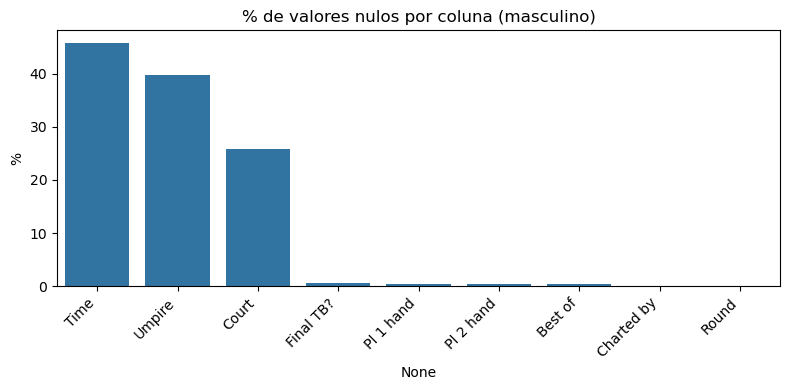

In [5]:
nulls = df_men.isnull().sum().sort_values(ascending=False)
null_pct = (nulls / len(df_men) * 100).round(2)
null_df = nulls[nulls > 0].to_frame(name="count")
null_df["pct"] = null_pct[null_pct > 0]
print(null_df)

plt.figure(figsize=(8, 4))
sns.barplot(x=null_df.index, y=null_df["pct"])
plt.title("% de valores nulos por coluna (masculino)")
plt.ylabel("%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Distribuicao temporal (Year)

Periodo: 1960 - 2026
Datas invalidas: 1


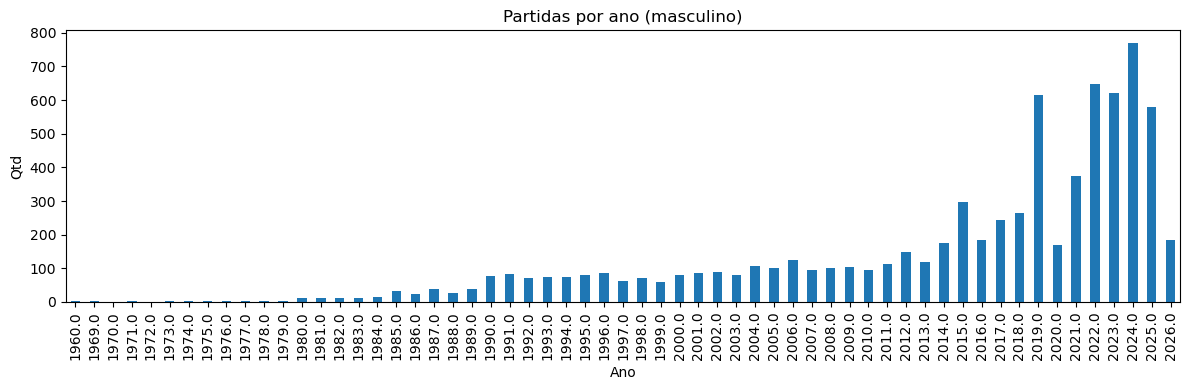

In [6]:
df_men["Date_parsed"] = pd.to_datetime(df_men["Date"], format="%Y%m%d", errors="coerce")
df_men["Year"] = df_men["Date_parsed"].dt.year

print(f"Periodo: {df_men['Year'].min():.0f} - {df_men['Year'].max():.0f}")
print(f"Datas invalidas: {df_men['Year'].isna().sum()}")

plt.figure(figsize=(12, 4))
df_men["Year"].value_counts().sort_index().plot(kind="bar")
plt.title("Partidas por ano (masculino)")
plt.xlabel("Ano")
plt.ylabel("Qtd")
plt.tight_layout()
plt.show()

## Surface

Surface
Hard                  4850
Clay                  1877
Grass                  837
Eva Asderaki-Moore       1
3                        1
Name: count, dtype: int64


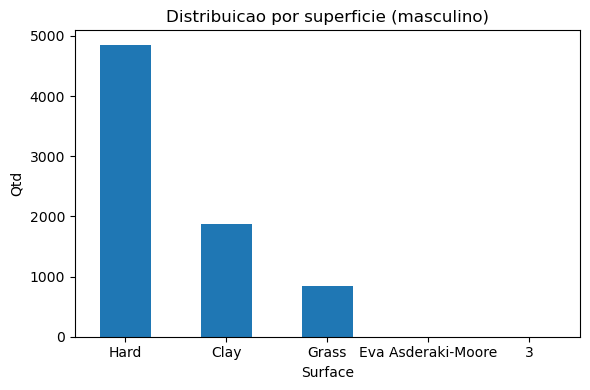

In [7]:
print(df_men["Surface"].value_counts())

plt.figure(figsize=(6, 4))
df_men["Surface"].value_counts().plot(kind="bar")
plt.title("Distribuicao por superficie (masculino)")
plt.ylabel("Qtd")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Round

Round
R32             1279
F               1209
SF              1184
R16             1069
QF              1029
R64              781
R128             524
RR               424
Q1                26
Q3                18
Q2                12
BR                 7
Unipol Arena       1
PO                 1
PQ                 1
Name: count, dtype: int64


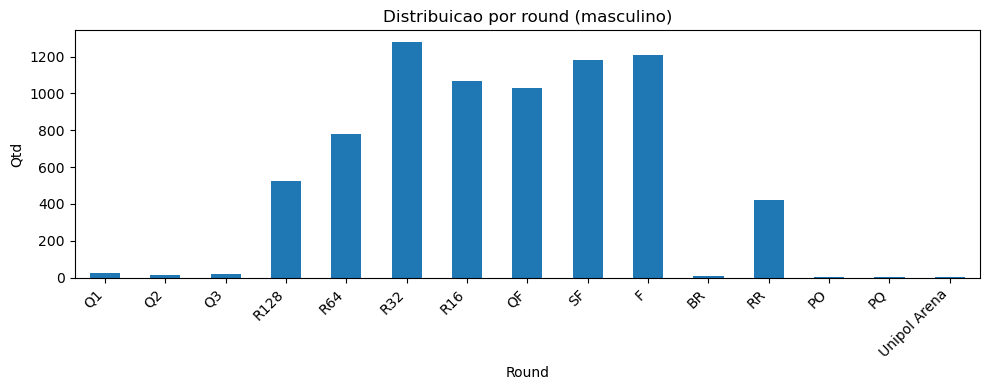

In [8]:
round_order = ["Q1","Q2","Q3","R128","R64","R32","R16","QF","SF","F","BR","RR","PO","PQ"]
round_counts = df_men["Round"].value_counts()
print(round_counts)

plt.figure(figsize=(10, 4))
ordered = [r for r in round_order if r in round_counts.index]
others = [r for r in round_counts.index if r not in round_order]
round_counts[ordered + others].plot(kind="bar")
plt.title("Distribuicao por round (masculino)")
plt.ylabel("Qtd")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Best of

Best of
3           5202
5           2329
1              1
Zindaras       1
Name: count, dtype: int64


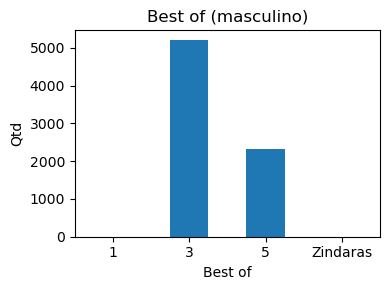

In [9]:
print(df_men["Best of"].value_counts())

plt.figure(figsize=(4, 3))
df_men["Best of"].value_counts().sort_index().plot(kind="bar")
plt.title("Best of (masculino)")
plt.ylabel("Qtd")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Lateralidade (Pl 1 hand / Pl 2 hand)

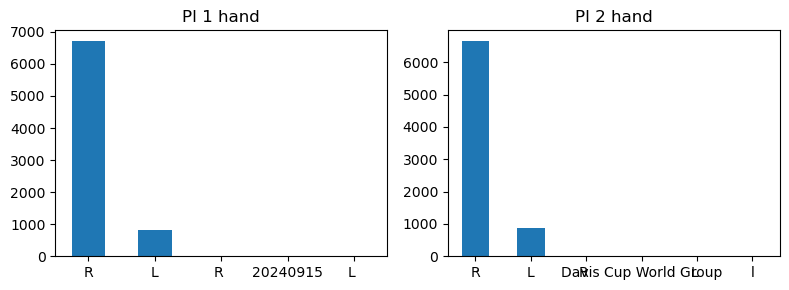

Handedness_Matchup
RR                               5950
RL                                760
LR                                706
LL                                 97
UU                                 33
R L                                 9
LR                                  3
R R                                 2
R R                                 2
20240915Davis Cup World Group       1
L R                                 1
RL                                  1
Rl                                  1
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
df_men["Pl 1 hand"].value_counts().plot(kind="bar", ax=axes[0], title="Pl 1 hand")
df_men["Pl 2 hand"].value_counts().plot(kind="bar", ax=axes[1], title="Pl 2 hand")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

df_men["Handedness_Matchup"] = df_men["Pl 1 hand"].fillna("U") + df_men["Pl 2 hand"].fillna("U")
print(df_men["Handedness_Matchup"].value_counts())

## Top 20 torneios

Tournament
Australian Open         591
US Open                 547
Wimbledon               484
Roland Garros           437
Indian Wells Masters    337
Miami Masters           280
Monte Carlo Masters     237
Tour Finals             234
Paris Masters           229
Rome Masters            229
Madrid Masters          211
Canada Masters          211
Cincinnati Masters      188
Rotterdam               146
Shanghai Masters        125
Dubai                   108
Halle                    84
Basel                    83
Queens Club              82
Doha                     80
Name: count, dtype: int64


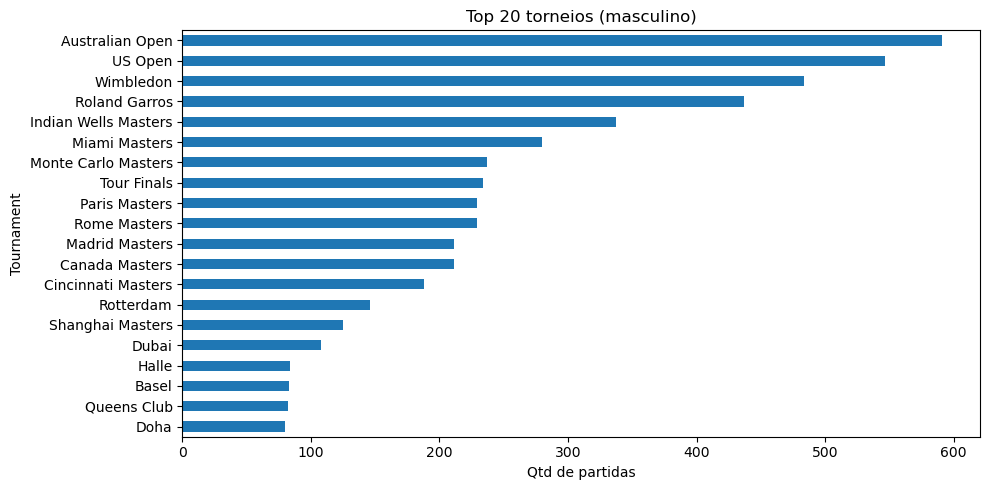

In [11]:
top20 = df_men["Tournament"].value_counts().head(20)
print(top20)

plt.figure(figsize=(10, 5))
top20.plot(kind="barh")
plt.title("Top 20 torneios (masculino)")
plt.xlabel("Qtd de partidas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Final TB? e Has_Umpire

In [12]:
print("Final TB?:")
print(df_men["Final TB?"].value_counts(dropna=False))
print()
has_umpire = (df_men["Umpire"].notna() & (df_men["Umpire"] != "")).sum()
print(f"Com umpire:  {has_umpire} ({has_umpire/len(df_men)*100:.1f}%)")
print(f"Sem umpire:  {len(df_men)-has_umpire} ({(len(df_men)-has_umpire)/len(df_men)*100:.1f}%)")

Final TB?:
Final TB?
1      5719
0      1003
A       695
T        59
NaN      42
N        20
S        14
V        10
A         3
W         1
Name: count, dtype: int64

Com umpire:  4562 (60.3%)
Sem umpire:  3004 (39.7%)
